In [1]:
import mlflow
import os

# Локальное хранилище экспериментов (создастся папка ./mlruns)
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Credit_Prediction_Experiments")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
z:\projects\AIE\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:z:/projects/AIE/project/notebooks/mlruns/954481753019458928', creation_time=1778264615812, experiment_id='954481753019458928', last_update_time=1778264615812, lifecycle_stage='active', name='Credit_Prediction_Experiments', tags={}, trace_location=None, workspace='default'>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
FIGURES_DIR = Path('../artifacts/lin_reg/')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

seed = 42
np.random.seed(seed)

In [3]:
df = pd.read_csv('../data/CreditPrediction.csv')

In [4]:
df.head(10)

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19
0,768805383,45.0,M,3,High School,Married,$60K - $80K,Blue,39.0,5.0,1,3,12691.0,777,1.335,1144,42,1.625,0.061,NaN
1,818770008,49.0,F,5,Graduate,NaN,Less than $40K,Blue,44.0,6.0,1,2,8256.0,864,1.541,1291,33,3.714,0.105,NaN
2,713982108,51.0,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1,0,3418.0,0,2.594,1887,20,2.333,0.000,NaN
3,769911858,40.0,F,4,High School,NaN,Less than $40K,Blue,34.0,3.0,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,NaN
4,709106358,40.0,M,3,Uneducated,Married,$60K - $80K,NaN,21.0,5.0,1,0,4716.0,0,2.175,816,28,2.500,0.000,NaN
5,713061558,44.0,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3.0,1,2,4010.0,1247,1.376,1088,24,0.846,0.311,NaN
6,810347208,51.0,M,4,Unknown,Married,$120K +,Gold,46.0,6.0,1,3,34516.0,2264,1.975,1330,31,0.722,0.066,NaN
7,818906208,32.0,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2.0,2,2,29081.0,1396,2.204,1538,36,0.714,0.048,NaN
8,710930508,37.0,M,3,Uneducated,Single,$60K - $80K,NaN,36.0,5.0,2,0,22352.0,2517,3.355,1350,24,1.182,0.113,NaN
9,719661558,48.0,M,2,Graduate,Single,$80K - $120K,Blue,36.0,6.0,3,3,11656.0,1677,1.524,1441,32,0.882,0.144,NaN


In [5]:
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])

In [6]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10167.000000,10167.000000,9944.000000,10147.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000
mean,46.753817,2.346513,35.913415,3.813245,2.341595,2.455887,8632.552346,1162.176748,0.759721,4402.349661,64.864463,0.712192,0.274716
std,13.520505,1.298701,7.980102,1.554741,1.010502,1.105580,9087.333842,815.082643,0.219054,3393.953441,23.461680,0.237934,0.275638
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2556.500000,348.500000,0.631000,2155.500000,45.000000,0.582000,0.022000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,0.736000,3900.000000,67.000000,0.702000,0.175000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1783.000000,0.859000,4740.000000,81.000000,0.818000,0.502500
max,352.330517,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10167 non-null  float64
 1   Gender                    9968 non-null   object 
 2   Dependent_count           10167 non-null  int64  
 3   Education_Level           10167 non-null  object 
 4   Marital_Status            8217 non-null   object 
 5   Income_Category           10167 non-null  object 
 6   Card_Category             8243 non-null   object 
 7   Months_on_book            9944 non-null   float64
 8   Total_Relationship_Count  10147 non-null  float64
 9   Months_Inactive_12_mon    10167 non-null  int64  
 10  Contacts_Count_12_mon     10167 non-null  int64  
 11  Credit_Limit              10167 non-null  float64
 12  Total_Revolving_Bal       10167 non-null  int64  
 13  Total_Amt_Chng_Q4_Q1      10167 non-null  float64
 14  Total_

In [8]:
df = df[(df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10150


In [20]:
df = df[(df['Total_Amt_Chng_Q4_Q1'] <= 2.8) & (df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10148


In [21]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [22]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' 'Unknown']

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'Post-Graduate'
 'Doctorate' 'College']

Marital_Status - ['Married' 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' 'Unknown' 'Gold' 'Silver' 'Platinum']



In [23]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

In [24]:
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

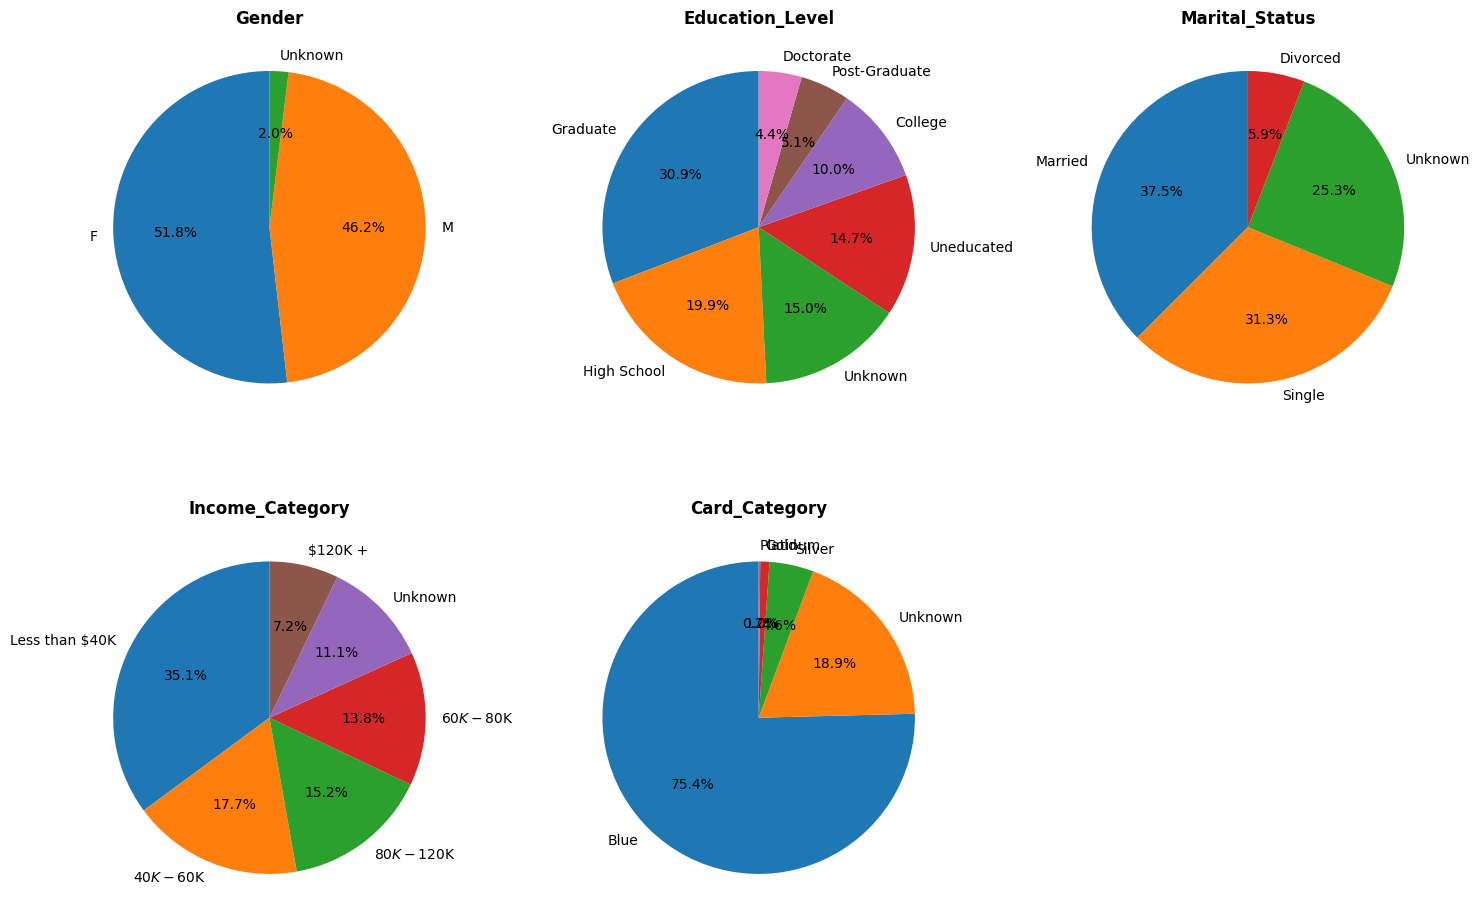

In [ ]:
# Диаграммы пирогов для категориальных признаков
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for idx, col_name in enumerate(cat_cols):
    value_counts = df[col_name].value_counts()
    axes[idx].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(col_name, fontsize=12, fontweight='bold')

# Удаляем пустые оси если колонок меньше чем ячеек в сетке
for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
out = FIGURES_DIR / "categorical_pies.png"
plt.savefig(out, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6088 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


In [15]:
import json
import hashlib

config = {
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": "RobustScaler",
    "model": "LinearRegression",
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80"
}

# Сохраняем конфиг в файл, чтобы позже залогировать как артефакт
with open("../artifacts/LR_mlflow/config.json", "w+") as f:
    json.dump(config, f, indent=2)

# Считаем хеш исходных данных (для воспроизводимости)
data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

Data hash: 0c491eccf4a9959c9cefab0a27497604


In [27]:
import joblib
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_lin_reg_base.pkl")

['../artifacts/target_encoder_lin_reg_base.pkl']

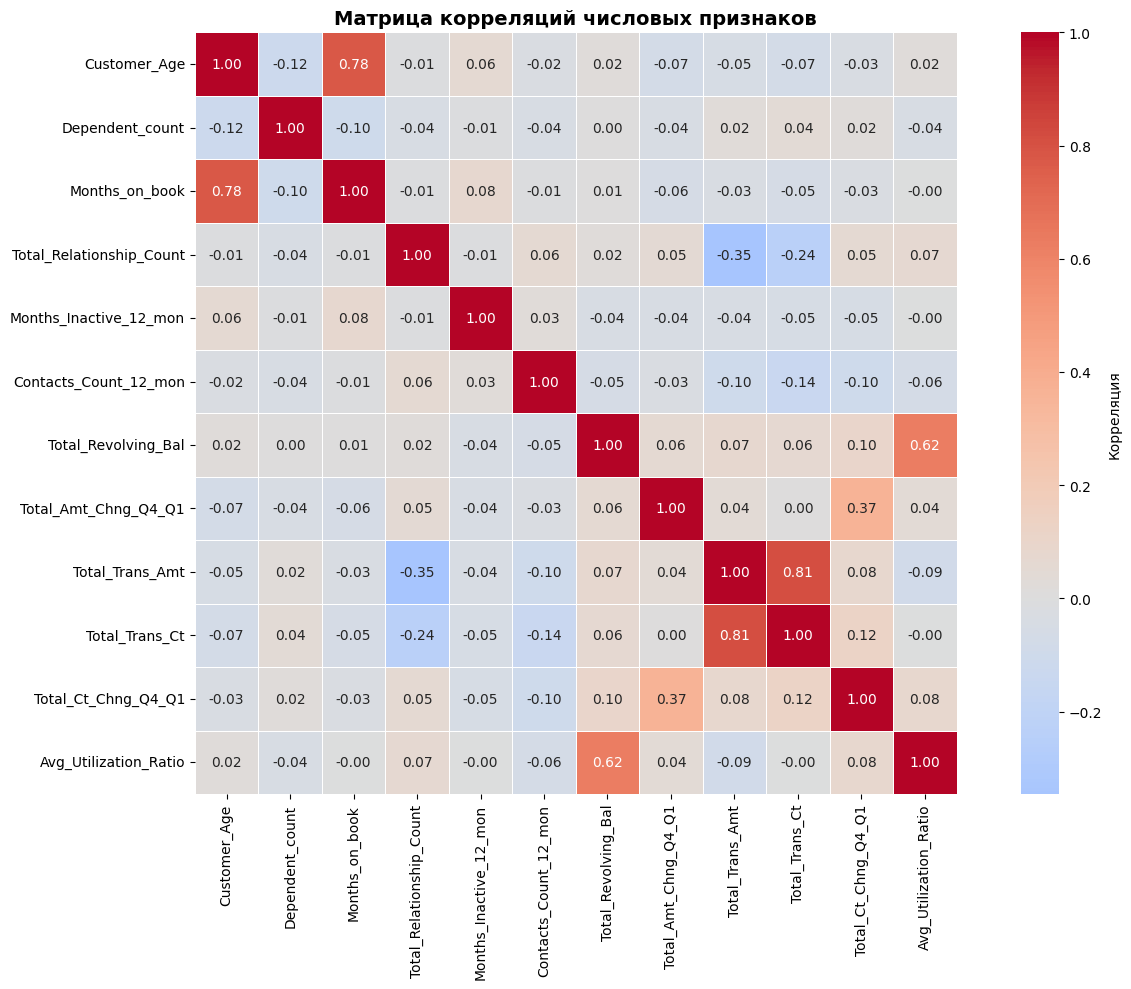

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = X_train_enc[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляций числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
out = FIGURES_DIR / "correlation_matrix.png"
plt.savefig(out, bbox_inches='tight')
plt.show()

In [29]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

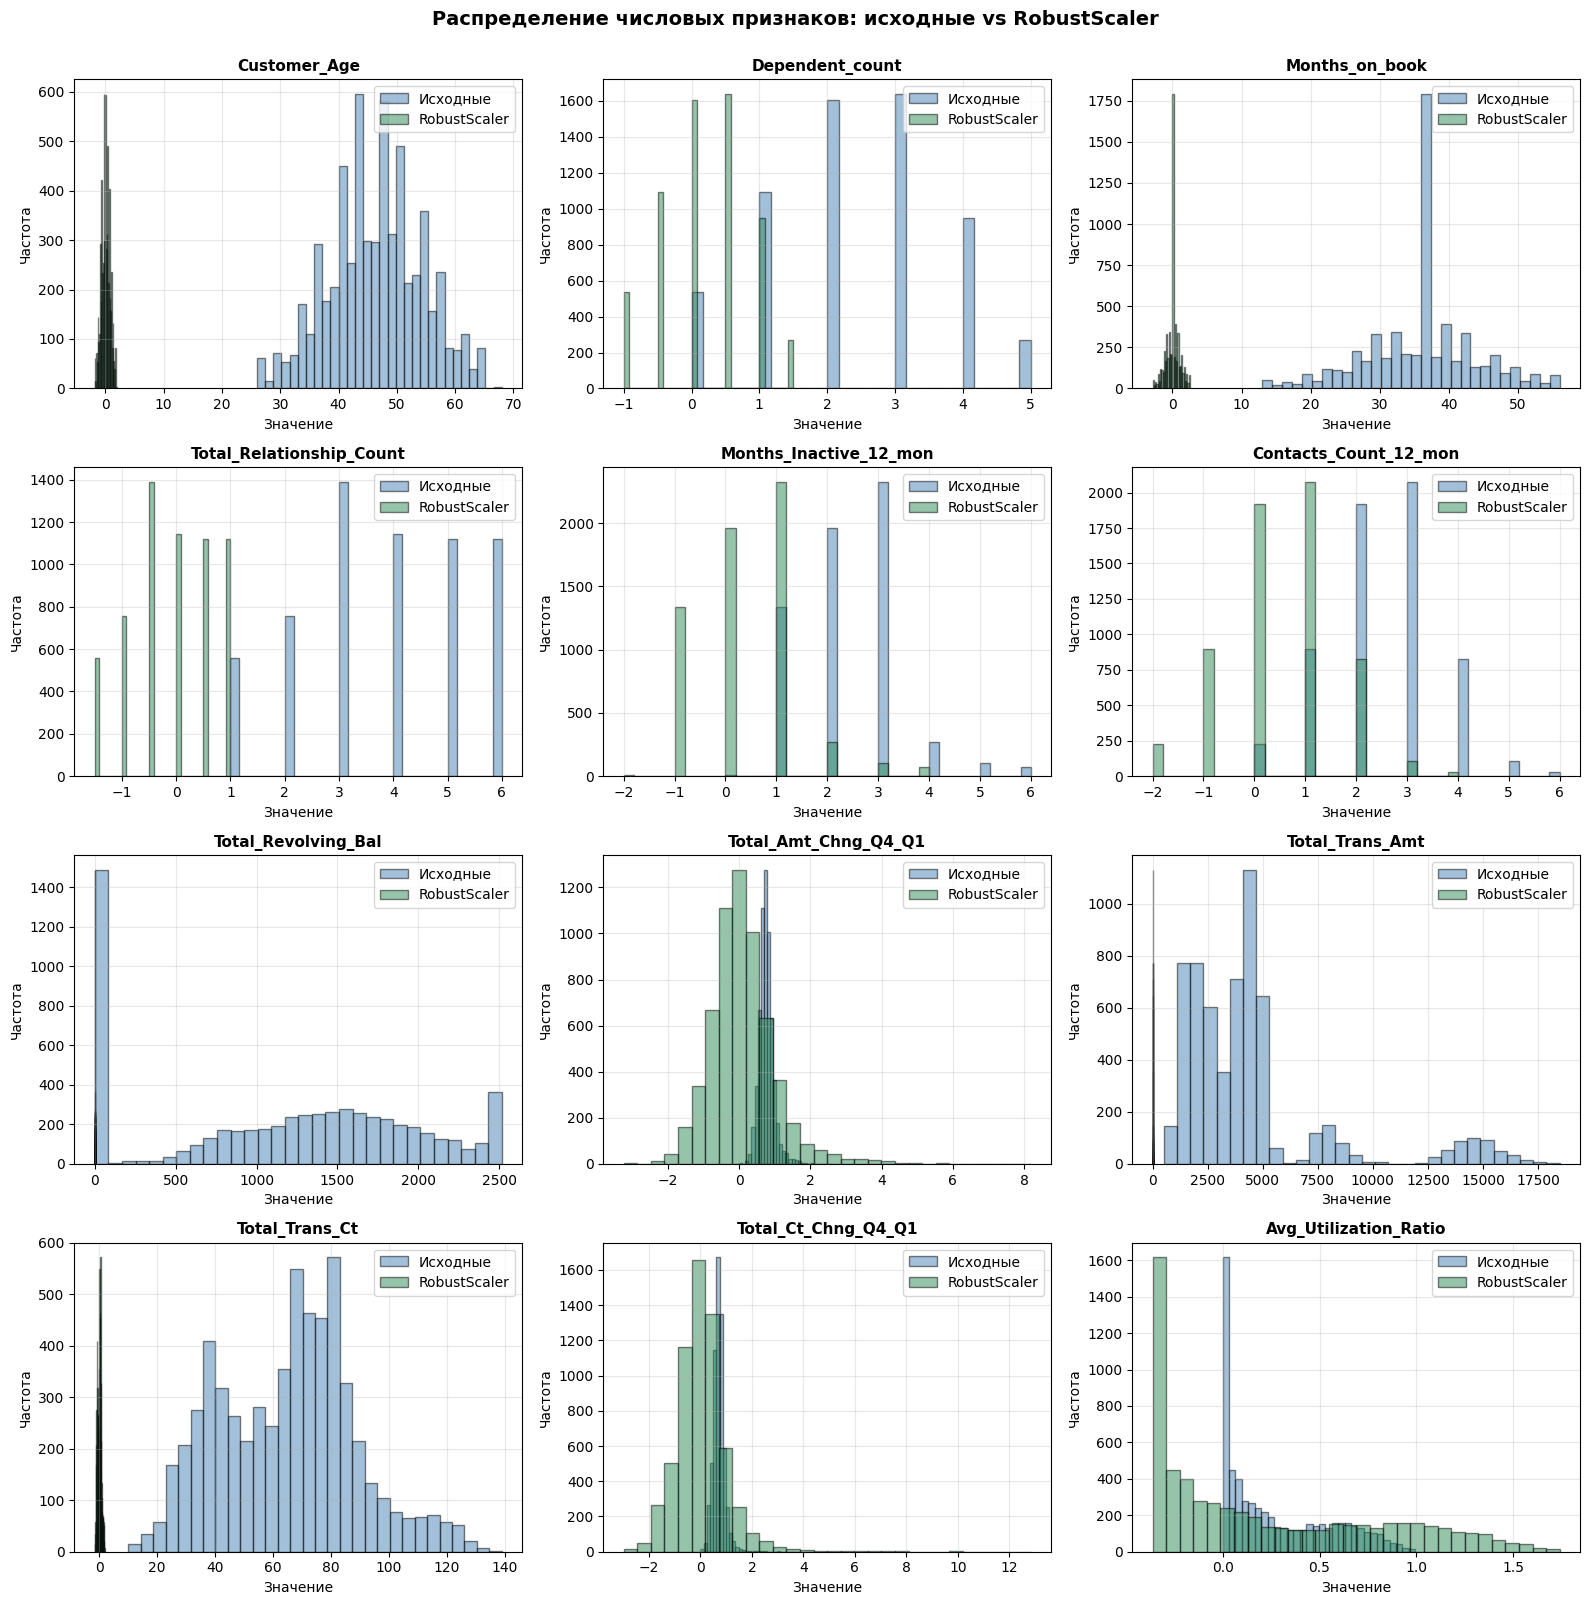

In [ ]:
n_cols_hist = 3
n_rows_hist = (len(num_cols) + n_cols_hist - 1) // n_cols_hist

fig, axes = plt.subplots(n_rows_hist, n_cols_hist, figsize=(16, 4 * n_rows_hist))
axes = axes.flatten()

for idx, col_name in enumerate(num_cols):
    axes[idx].hist(X_train_enc[col_name], bins=30, alpha=0.5, color='steelblue', edgecolor='black', label='Исходные')
    axes[idx].hist(X_train_scaled[:, X_train_enc.columns.get_loc(col_name)], bins=30, alpha=0.5, color='seagreen', edgecolor='black', label='RobustScaler')
    axes[idx].set_title(f'{col_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

for idx in range(len(num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Распределение числовых признаков: исходные vs RobustScaler', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
out = FIGURES_DIR / "original_vs_robust.png"
plt.savefig(out, bbox_inches='tight')
plt.show()

In [31]:
# c fillna для категорий

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики модели линейной регрессии')
print('=' * 50)

train_metrics = calculate_metrics(y_train, y_train_pred, 'TRAIN')
val_metrics = calculate_metrics(y_val, y_val_pred, 'VALIDATION')
test_metrics = calculate_metrics(y_test, y_test_pred, 'TEST')

print('\n' + '=' * 50)
print(f'Коэффициент модели (intercept): {model.intercept_:.4f}')
print(f'Количество признаков: {len(model.coef_)}')
print('=' * 50)

# joblib.dump(model, '../artifacts/linear_regression_model.pkl')
# print("Модель сохранена")

Метрики модели линейной регрессии

TRAIN:
  MSE:  30352791.2264
  RMSE: 5509.3367
  MAE:  3980.6278
  R²:   0.6406

VALIDATION:
  MSE:  29056194.1835
  RMSE: 5390.3798
  MAE:  3893.8449
  R²:   0.6289

TEST:
  MSE:  29657788.5735
  RMSE: 5445.8965
  MAE:  4006.3906
  R²:   0.6337

Коэффициент модели (intercept): 7735.6394
Количество признаков: 17


In [19]:
# без fillna для категорий

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

def calculate_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики модели линейной регрессии')
print('=' * 50)

train_metrics = calculate_metrics(y_train, y_train_pred, 'TRAIN')
val_metrics = calculate_metrics(y_val, y_val_pred, 'VALIDATION')
test_metrics = calculate_metrics(y_test, y_test_pred, 'TEST')

print('\n' + '=' * 50)
print(f'Коэффициент модели (intercept): {model.intercept_:.4f}')
print(f'Количество признаков: {len(model.coef_)}')
print('=' * 50)

joblib.dump(model, '../artifacts/linear_regression_model.pkl')
print("Модель сохранена")

Метрики модели линейной регрессии

TRAIN:
  MSE:  29454791.2208
  RMSE: 5427.2268
  MAE:  3910.5151
  R²:   0.6361

VALIDATION:
  MSE:  31265202.5310
  RMSE: 5591.5295
  MAE:  4107.1585
  R²:   0.6415

TEST:
  MSE:  30011452.6880
  RMSE: 5478.2710
  MAE:  3986.3567
  R²:   0.6358

Коэффициент модели (intercept): 7822.4337
Количество признаков: 17
Модель сохранена


In [24]:
with mlflow.start_run(run_name="linear_regression_baseline"):
    
    # 1. Параметры
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("scaler", "RobustScaler")
    mlflow.log_param("encoder", "TargetEncoder")
    mlflow.log_param("smoothing", 10.0)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("data_alteration", "Only age<=80")
    
    # 2. Метрики
    mlflow.log_metrics({
        "train_r2": train_metrics["R2"],
        "train_rmse": train_metrics["RMSE"],
        "train_mae": train_metrics["MAE"],
        "val_r2": val_metrics["R2"],
        "val_rmse": val_metrics["RMSE"],
        "val_mae": val_metrics["MAE"],
        "test_r2": test_metrics["R2"],
        "test_rmse": test_metrics["RMSE"],
        "test_mae": test_metrics["MAE"]
    })
    
    # 3. Хеш данных (из предыдущей ячейки)
    data_path = "../data/CreditPrediction.csv"
    with open(data_path, "rb") as f:
        data_hash = hashlib.md5(f.read()).hexdigest()
    mlflow.log_param("data_hash", data_hash)
    
    # 4. Артефакты: модель и конфигурация
    joblib.dump(model, '../artifacts/linear_regression_model.pkl')
    mlflow.sklearn.log_model(model, "model")
    mlflow.log_artifact("../artifacts/LR_mlflow/config.json")       # если сохранили конфиг в файл
    mlflow.log_artifact(data_path, "data")                # оригинальный датасет
    
    # 5. (Опционально) Если хотите залогировать какой-то график, например, матрицу корреляций,
    #    то постройте его здесь и вызовите mlflow.log_figure(...)
    
    print("Модель и метрики залогированы в MLflow.")

2026/05/08 23:28:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 23:28:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Модель и метрики залогированы в MLflow.


In [25]:
# === Новая ячейка (сводка) ===
import mlflow

experiment = mlflow.get_experiment_by_name("Credit_Prediction_Experiments")
if experiment:
    runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    cols_to_show = [
        "run_id",
        "start_time",
        "metrics.test_r2",
        "metrics.test_rmse",
        "metrics.train_r2",
        "params.model_type"
    ]
    # Показываем только существующие столбцы
    available_cols = [c for c in cols_to_show if c in runs_df.columns]
    summary = runs_df[available_cols].sort_values("metrics.test_r2", ascending=False)
    print("Текущие запуски в эксперименте:")
    print(summary.to_string())
else:
    print("Эксперимент 'Credit_Prediction_Experiments' не найден.")

Текущие запуски в эксперименте:
                             run_id                       start_time  metrics.test_r2  metrics.test_rmse  metrics.train_r2 params.model_type
0  6114d160f781487baa089170a3e5c7cc 2026-05-08 20:28:24.336000+00:00         0.635779        5478.270958          0.636147  LinearRegression
1  e37101a45d8548009337a8f643b82ac3 2026-05-08 20:11:59.591000+00:00         0.635779        5478.270958          0.636147  LinearRegression
2  b4115d001bea4a08ae1de38f666982ec 2026-05-08 18:46:32.956000+00:00         0.633671        5445.896489          0.640557  LinearRegression


In [ ]:
# # без dropna для категорий

# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import cross_validate, KFold
# from sklearn.base import BaseEstimator, TransformerMixin

# class TargetEncoderTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cols, smoothing=10.0):
#         self.cols = cols
#         self.smoothing = smoothing
#         self.encoder = None
        
#     def fit(self, X, y=None):
#         from category_encoders import TargetEncoder
#         self.encoder = TargetEncoder(cols=self.cols, smoothing=self.smoothing, handle_unknown='value')
#         self.encoder.fit(X, y)
#         return self
    
#     def transform(self, X):
#         return self.encoder.transform(X)

# pipeline = Pipeline([
#     ('target_encoder', TargetEncoderTransformer(cols=cat_cols, smoothing=10.0)),
#     ('robust_scaler', RobustScaler()),
#     ('linear_regression', LinearRegression())
# ])

# kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# scoring = {
#     'r2': 'r2',
#     'neg_mse': 'neg_mean_squared_error',
#     'neg_mae': 'neg_mean_absolute_error',
# }

# print('=' * 70)
# print('КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (5-Fold CV)')
# print('=' * 70)

# cv_results = cross_validate(pipeline, X, y, cv=kfold, scoring=scoring, return_train_score=True)

# cv_results['test_rmse'] = np.sqrt(-cv_results['test_neg_mse'])
# cv_results['train_rmse'] = np.sqrt(-cv_results['train_neg_mse'])
# cv_results['test_mae'] = -cv_results['test_neg_mae']
# cv_results['train_mae'] = -cv_results['train_neg_mae']

# print('\nРезультаты для каждого fold\'а:')
# print('-' * 70)
# for fold in range(kfold.n_splits):
#     print(f'\nFold {fold + 1}:')
#     print(f'  Train R²:     {cv_results["train_r2"][fold]:.4f}')
#     print(f'  Test R²:      {cv_results["test_r2"][fold]:.4f}')
#     print(f'  Train RMSE:   {cv_results["train_rmse"][fold]:.4f}')
#     print(f'  Test RMSE:    {cv_results["test_rmse"][fold]:.4f}')
#     print(f'  Train MAE:    {cv_results["train_mae"][fold]:.4f}')
#     print(f'  Test MAE:     {cv_results["test_mae"][fold]:.4f}')

# print('\n' + '=' * 70)
# print('СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ FOLD\'ЫМ:')
# print('=' * 70)

# print(f'\nR² Score:')
# print(f'  Среднее (Train):  {cv_results["train_r2"].mean():.4f} ± {cv_results["train_r2"].std():.4f}')
# print(f'  Среднее (Test):   {cv_results["test_r2"].mean():.4f} ± {cv_results["test_r2"].std():.4f}')

# print(f'\nRMSE:')
# print(f'  Среднее (Train):  {cv_results["train_rmse"].mean():.4f} ± {cv_results["train_rmse"].std():.4f}')
# print(f'  Среднее (Test):   {cv_results["test_rmse"].mean():.4f} ± {cv_results["test_rmse"].std():.4f}')

# print(f'\nMAE:')
# print(f'  Среднее (Train):  {cv_results["train_mae"].mean():.4f} ± {cv_results["train_mae"].std():.4f}')
# print(f'  Среднее (Test):   {cv_results["test_mae"].mean():.4f} ± {cv_results["test_mae"].std():.4f}')

# print('\n' + '=' * 70)
# print('АНАЛИЗ ПЕРЕОБУЧЕНИЯ:')
# print('=' * 70)
# overfitting_r2 = cv_results["train_r2"].mean() - cv_results["test_r2"].mean()
# print(f'\nРазница R² (Train - Test): {overfitting_r2:.4f}')
# if overfitting_r2 > 0.05:
#     print('Обнаружены признаки переобучения (разница > 0.05)')
# else:
#     print('Модель хорошо обобщается на новые данные')

# print('\n' + '=' * 70)

КРОСС-ВАЛИДАЦИЯ ЛИНЕЙНОЙ РЕГРЕССИИ (5-Fold CV)

Результаты для каждого fold'а:
----------------------------------------------------------------------

Fold 1:
  Train R²:     0.6386
  Test R²:      0.6346
  Train RMSE:   5474.8148
  Test RMSE:    5439.0070
  Train MAE:    3961.4570
  Test MAE:     4009.9718

Fold 2:
  Train R²:     0.6327
  Test R²:      0.6530
  Train RMSE:   5448.7040
  Test RMSE:    5566.7144
  Train MAE:    3954.9068
  Test MAE:     3997.5384

Fold 3:
  Train R²:     0.6394
  Test R²:      0.6283
  Train RMSE:   5504.0086
  Test RMSE:    5328.2178
  Train MAE:    4006.3012
  Test MAE:     3880.8132

Fold 4:
  Train R²:     0.6356
  Test R²:      0.6409
  Train RMSE:   5452.3743
  Test RMSE:    5564.4203
  Train MAE:    3944.9132
  Test MAE:     4004.0351

Fold 5:
  Train R²:     0.6434
  Test R²:      0.6132
  Train RMSE:   5450.2667
  Test RMSE:    5543.3424
  Train MAE:    3945.3099
  Test MAE:     3996.2049

СРЕДНИЕ ЗНАЧЕНИЯ ПО ВСЕМ FOLD'ЫМ:

R² Score:
  Среднее